In [1]:
import numpy as np
from scipy import stats as st
from scipy import special as sp
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, to_rgba
import seaborn as sns
import pandas as pd
import os
import json
import decimal
from itertools import product
from scipy import ndimage


In [2]:
root_dir = '../simulations'
params_path = os.path.join(root_dir, 'map_params.json')
params = json.load(open(params_path))

# Read map parameters.
eps = params['eps']
alpha = params['alpha']
ps = {1: params['p1'], 2: params['p2']} # misclassification rates
Ns = {1: params['N1dot']*params['px_per_km2'], 2: params['N2dot']*params['px_per_km2']} # mapped areas (pixels)

In [3]:
red = '#ff0000'
cyan = '#00eeee'
grey = "#808080"
dark = "#07051b"
sns.set_style('darkgrid')

# 2. $\mathrm{Pr}(\mathrm{distance}(N_{\bullet 1}, \mathrm{CI}) > d)$

### Setup

In [4]:
max_d = .5
max_n = 1000
n_ds = 200
n_ns = 200

ds = np.linspace(0, max_d, num=n_ds+1)
ns = np.linspace(0, max_n, num=n_ns+1)[1:].astype(int)

In [5]:
P_COL = 'population proportion'
N_COL = 'sample size'
PROB_COL = 'probability of zero false negatives'

### Calculate $\mathrm{Pr}(\mathrm{distance}(N_{\bullet 1}, \mathrm{CI}) > d)$ for each $d, n$

In [6]:
%%time
annot = False

ds = np.linspace(0, max_d, num=n_ds+1)
ns = np.linspace(0, max_n, num=n_ns+1)[1:].astype(int)

N = sum(Ns.values())
N_dot1 = Ns[1]*(1-ps[1]) + Ns[2]*ps[2]
z = st.norm.ppf(1 - alpha/2)


def allocated_sample_sizes(n):
    n2 = int(np.round((n-2) / (1 + Ns[1]/Ns[2]*(ps[1]*(1-ps[1])/ps[2]/(1-ps[2]))**.5))) + 1
    return n - n2, n2


def exceedance_by_d(distance_prop, Pr):
    """Return Pr(distance_prop > d) for every d in ds."""
    order = np.argsort(distance_prop.ravel())
    sorted_distance = distance_prop.ravel()[order]
    sorted_prob = Pr.ravel()[order]
    cum_prob = np.cumsum(sorted_prob)

    idx = np.searchsorted(sorted_distance, ds, side='right')
    return 1 - np.where(idx > 0, cum_prob[idx - 1], 0.0)


probs_too_low = np.empty((len(ds), len(ns)), dtype=float)
probs_too_high = np.empty_like(probs_too_low)

for col, n in enumerate(ns):
    n1, n2 = allocated_sample_sizes(n)

    x1 = np.arange(n1 + 1)[:, None]
    x2 = np.arange(n2 + 1)[None, :]

    p_x1 = st.binom.pmf(np.arange(n1 + 1), n1, ps[1])
    p_x2 = st.binom.pmf(np.arange(n2 + 1), n2, ps[2])
    Pr = np.outer(p_x1, p_x2)

    N_dot1_hat = Ns[1]*(1 - x1/n1) + Ns[2]*x2/n2
    std = (Ns[1]**2*x1*(n1-x1)/n1**3 + Ns[2]**2*x2*(n2-x2)/n2**3)**.5

    U = N_dot1_hat + z*std
    L = N_dot1_hat - z*std

    probs_too_low[:, col] = exceedance_by_d((N_dot1 - U)/N_dot1, Pr)
    probs_too_high[:, col] = exceedance_by_d((L - N_dot1)/N_dot1, Pr)

probs = np.clip(probs_too_low + probs_too_high, 0, 1)

CPU times: total: 109 ms
Wall time: 129 ms


### Plot

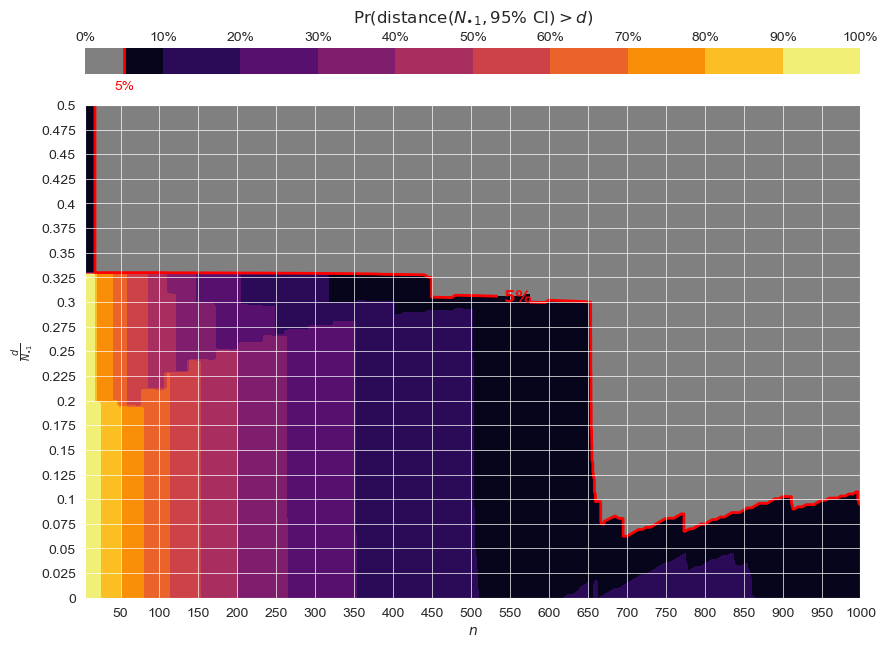

In [7]:
df = pd.DataFrame(probs, index=ds, columns=ns)

n_ylabels = 20
n_xlabels = 20
n_contours = 11
annot = False

fig, ax = plt.subplots(figsize=(10,8))

color_levels = [0, .05] + list(np.linspace(.1, 1, n_contours - 1))

n_bands = len(color_levels) - 1
# Compute each band’s midpoint, normalized to [0,1]
lo, hi = color_levels[0], color_levels[-1]
mid_norm = [
    (0.5 * (color_levels[i] + color_levels[i + 1]) - lo) / (hi - lo)
    for i in range(n_bands)
]
# Sample Inferno at those midpoints
base_colors = plt.cm.inferno(np.array(mid_norm))
# Replace the first bands' colors
base_colors[0] = to_rgba(grey)
base_colors[1] = to_rgba(dark)
# Build a ListedColormap of length 11
my_inferno = ListedColormap(base_colors)

# BoundaryNorm to map each [levels[i], levels[i+1]) → color index i
norm = BoundaryNorm(color_levels, ncolors=n_bands)

# Contours in actual data coordinates, not heatmap row/column coordinates.
x = df.columns.to_numpy(dtype=float)
y = df.index.to_numpy(dtype=float)
z = df.to_numpy()
cntrs = ax.contourf(x, y, z, levels=color_levels, cmap=my_inferno, norm=norm)

x_ticks = ns[n_ns // n_xlabels - 1::n_ns // n_xlabels]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, rotation=0)
if n_xlabels < n_ns:
    ax.xaxis.set_ticks_position('none')
for x_tick in x_ticks:
    ax.axvline(x_tick, color='w', lw=.5, zorder=3)

y_ticks = ds[::n_ds // n_ylabels]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{d:.3g}' for d in y_ticks], rotation=0)
if n_ylabels < n_ds:
    ax.yaxis.set_ticks_position('none')
for y_tick in y_ticks:
    ax.axhline(y_tick, color='w', lw=.5, zorder=3)

ax.set_xlabel('$n$')
ax.set_ylabel(r'$\frac{d}{N_{\bullet 1}}$')
ax.set_xlim(ns.min(), ns.max())
ax.set_ylim(ds.min(), ds.max())

cbar = plt.colorbar(cntrs, ax=ax, orientation='horizontal', location='top',
                    aspect=30, spacing='proportional')
cbar.set_ticks(color_levels)
cbar.set_ticklabels([f'{prob:.0%}' if prob != .05 else '' for prob in color_levels])
cbar.ax.tick_params(length=0)
cbar.ax.axvline(.05, color='red', lw=2)
plt.setp(cbar.ax.spines.values(), visible=False) 
cbar.ax.set_title(r'$\mathrm{Pr}(\text{distance}({N}_{\bullet 1}, \text{95\% CI}) > d)$')
for label in cbar.ax.get_xticklabels():
    if label.get_text() == '5%':
        label.set_color('red')
cbar.ax.text(
    .05, -.25, '5%', transform=cbar.ax.transAxes,
    ha='center', va='top', color='red'
)

# 5% contour
cntr = ax.contour(x, y, z, [0.05], colors='red', linewidths=2)
texts = ax.clabel(cntr, inline=True, fmt=lambda x: r'$\bf 5\%$', fontsize=12, manual=[(560, .305)])

# Draw cyan horizontal "contour"
# x = np.linspace(0, len(df.columns), len(df.columns) * smooth_scale)
# y = np.linspace(0, len(df.index), len(df.index) * smooth_scale)
# X, Y = np.meshgrid(x, y)
# Z = Y
# horiz_cntr = ax.contour(X, Y, Z, levels=[0], colors=cyan, linewidths=4)
# texts = ax.clabel(horiz_cntr, inline=True, fmt=lambda x: r'$\bf 5\%$', fontsize=12, manual=[(100, 100)])
# for txt in texts:
#     txt.set_verticalalignment('bottom')

plt.savefig(f'2_Pr(distance_to_CI).png', bbox_inches='tight', dpi=600)

In [8]:
# first strictly positive d
j = np.where(ds > 0)[0][0]

probs_too_low = np.array(probs_too_low)
probs_too_high = np.array(probs_too_high)
p_under = np.asarray(probs_too_low[j, :], dtype=float)   # U undershoots N_dot1
p_over  = np.asarray(probs_too_high[j, :], dtype=float)  # L overshoots N_dot1

p_any = p_under + p_over

# among missed CIs, fraction due to undershoot / overshoot
frac_under = np.divide(
    p_under, p_any,
    out=np.full_like(p_under, np.nan),
    where=p_any > 0
)

frac_over = np.divide(
    p_over, p_any,
    out=np.full_like(p_over, np.nan),
    where=p_any > 0
)

# odds under vs over
odds_under_over = np.divide(
    p_under, p_over,
    out=np.full_like(p_under, np.inf),
    where=p_over > 0
)

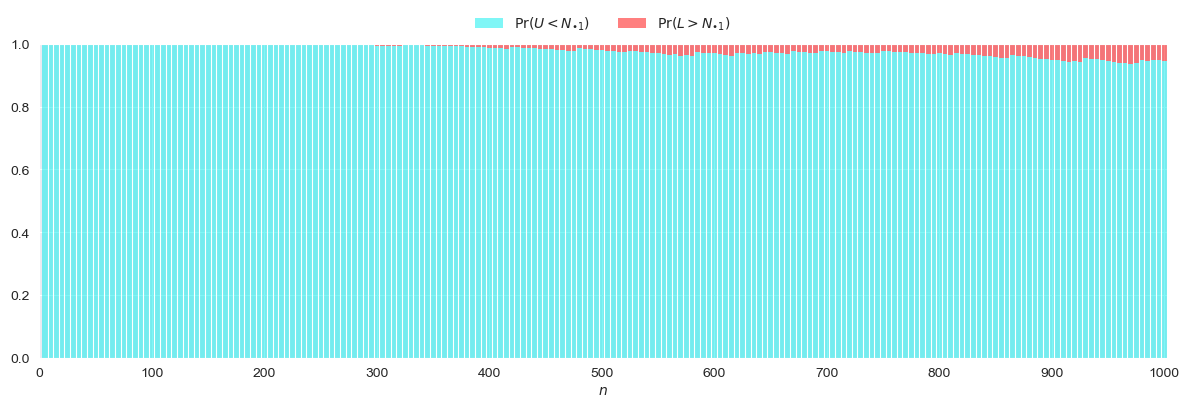

In [ ]:
j = 0

p_under = np.asarray(probs_too_low[j, :], dtype=float)
p_over  = np.asarray(probs_too_high[j, :], dtype=float)
p_any   = p_under + p_over

frac_under = np.divide(
    p_under, p_any,
    out=np.full_like(p_under, np.nan),
    where=p_any > 0
)
frac_over = np.divide(
    p_over, p_any,
    out=np.full_like(p_over, np.nan),
    where=p_any > 0
)

spacing = np.min(np.diff(ns))
bar_width = spacing   # no gap

under_color = cyan
over_color  = red
sep_color   = "white"   # or "black", "#dddddd", etc.
sep_lw      = 0.8
alpha = .5

fig, ax = plt.subplots(figsize=(12, 4.5))

# stacked bars with no outlines
ax.bar(
    ns,
    frac_under,
    width=bar_width,
    align="center",
    color=under_color,
    label=r"$\Pr(U < N_{\bullet 1})$",# | N_{\bullet 1} \notin [L, U])$",
    edgecolor="none",
    linewidth=0,
    alpha=alpha
)

ax.bar(
    ns,
    frac_over,
    width=bar_width,
    align="center",
    bottom=frac_under,
    color=over_color,
    label=r"$\Pr(L > N_{\bullet 1})$",# | N_{\bullet 1} \notin [L, U])$",
    edgecolor="none",
    linewidth=0,
    alpha=alpha
)

# vertical separators between adjacent bars only
boundaries = (ns[:-1] + ns[1:]) / 2
ax.vlines(boundaries, ymin=0, ymax=1, colors=sep_color, linewidth=sep_lw)

ax.set_xlabel("$n$")
# ax.set_ylabel("proportion of missed CIs")
ax.set_ylim(0, 1)
ax.set_xlim(ns.min() - spacing/2, ns.max() + spacing/2)
ax.set_xticks(np.arange(0, ns.max() + 1, 100))

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

plt.savefig(f'S1_Pr(directional_miss).png', bbox_inches='tight', dpi=600)